In [3]:
!pip install langchain_openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 1.7 MB/s eta 0:00:00a 0:00:01


In [10]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.messages import SystemMessage, HumanMessage
import operator

In [5]:
load_dotenv()

False

In [6]:
generator_llm = ChatOpenAI(model='gpt-4o-mini')
evaluator_llm = ChatOpenAI(model='gpt-4o-mini')
optimizer_llm = ChatOpenAI(model='gpt-4o-mini')

In [15]:
from pydantic import BaseModel, Field

class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

In [16]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [17]:
class TweetState(TypedDict):
    topic : str
    tweet : str
    evaluation : Literal['approved', 'needs_improvement']
    feedback : str
    iteration : int
    max_iteration : int
    
    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [18]:
def generator(state: TweetState):

    # prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    # send generator_llm
    response = generator_llm.invoke(messages).content

    # return response
    return {'tweet': response, 'tweet_history': [response]}

In [19]:
def evaluator(state: TweetState):

    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]

    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

In [20]:
def optimizor(state: TweetState):

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [21]:
def route_evaluation(state: TweetState):

    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

In [22]:
graph = StateGraph(TweetState)

graph.add_node('generator', generator)
graph.add_node('evaluator', evaluator)
graph.add_node('optimizor', optimizor)

graph.add_edge(START, 'generator')
graph.add_edge('generator', 'evaluator')

graph.add_conditional_edges('evaluator', route_evaluation, {'approved': END, 'needs_improvement': 'optimizor'})
graph.add_edge('optimizor', 'evaluator')

workflow = graph.compile()


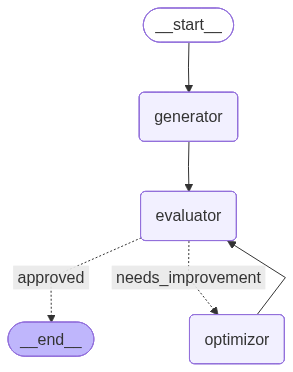

In [23]:
workflow

In [24]:
initial_state = {
    "topic": "Egdbeq",
    "iteration": 1,
    "max_iteration": 5
}
result = workflow.invoke(initial_state)

In [25]:
result

{'topic': 'Egdbeq',
 'tweet': 'Just found out "Egdbeq" is not the secret code for world domination, but my cat’s latest attempt at keyboard art. 🙄🐾 Who knew “let’s make a mess” was the theme of 2023? At this point, I\'m just waiting for the NFTs. #CatArtist #EgdbeqIn2023',
 'evaluation': 'approved',
 'feedback': "This tweet showcases a good level of originality, as the concept of attributing a nonsensical keyboard mash to a cat's 'art' is amusing and relatable for pet owners. The humor is subtle yet effective, particularly with the sarcastic undertone of the cat's messy contributions. While it could be tighter in structure, it remains within the 280-character limit and doesn't follow a traditional joke format, enhancing its scroll-stopping potential. The use of hashtags also targets a niche audience, increasing virality potential. Overall, it successfully engages with both cat lovers and humor enthusiasts.",
 'iteration': 1,
 'max_iteration': 5,
 'tweet_history': ['Just found out "Egdb